# Worm PIMC：从最短计算到逐步查看更新

这份 notebook 是《路径积分量子蒙特卡洛笔记》的可执行配套。先运行一个小计算，再把世界线的数据结构和九类更新逐一画出来。
默认是一维周期盒中的小系统；图中的横轴是位置 $x$，纵轴是虚时间 $\tau$。

中译名与笔记一致：**位移（Wiggle）**指固定端点之间的局部路径重采样，**平移（Displace）**指整个闭合世界线分量的整体平移。

**阅读顺序：** 最短计算 → 构型与周期边界 → 平移（Displace）/ 位移（Wiggle） → Open / Close → Advance / Recede → Swap → Insert / Remove。

每张更新图都保留 **更新前、候选、决策后** 三个面板。被拒绝的候选同样值得观察。

首次使用，在仓库根目录的终端执行：
```shell
python -m pip install -e ".[notebook]"
python -m jupyter lab examples/worm_walkthrough.ipynb
```
选择安装了上述依赖的 Python kernel，然后 **Restart Kernel and Run All Cells**。
各组演示从自己的 seed 重新初始化；重跑一组时，从该组的第一个代码单元开始。

本版使用静态内嵌图，可以直接上下滚动对照。控件和连续回放留到下一步。

In [1]:
from pathlib import Path
import sys
from dataclasses import replace

# 从仓库根目录或 examples 目录启动均可；也支持其子目录。
ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "wormpimc").is_dir() and (p / "examples").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("请在这个仓库内启动 notebook，以便导入共享绘图辅助。")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from wormpimc import Configuration, Simulation, SimulationConfig
from examples.notebook_helpers import display_table, show_configuration, show_step

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("Python:", sys.version.split()[0])
print("Repository:", ROOT.name)

Python: 3.14.5
Repository: L-L_model


## 1. 最短的带量测计算

下面的核心调用只有几行：配置 → 创建 simulation → 推进热化和量测 → 读取结果。
`particle_count` 控制初始粒子数，Worm 链运行后粒子数可以改变。此处使用正常随机选择更新。

In [2]:
config = SimulationConfig.small_system(
    n_slices=8, warmup_sweeps=5, measurement_sweeps=100, seed=97531,
)
measurement_sim = Simulation(config)
measurement_sim.advance()
result = measurement_sim.results()
result["scalars"]["particle_number"]

{'observable': 'particle_number',
 'mean': 0.1896551724137931,
 'standard_error': None,
 'uncorrected_standard_error': 0.05192539992843436,
 'n_measurements': 58,
 'n_effective': None,
 'blocking_level': None,
 'block_size_measurements': None,
 'n_blocks': None,
 'uncertainty_status': 'insufficient_blocking_levels',
 'estimator_variant': 'link_occupation',
 'sector': 'Z',
 'units': '1',
 'normalization_status': 'physical_z_conditional',
 'warning': 'insufficient_blocking_levels'}

把结果整理成表格。注意计划量测的机会数与实际在 Z 扇区得到的样本数不同；
`standard_error=None` 表示当前数据不足以给出相关样本的误差估计，表格用“—”显示它。
这次短运行用于检查调用流程，讨论物理结果时再延长链并检查 seed 和切片数。

In [3]:
display_table(
    ("观测量", "mean", "standard error", "Z samples", "uncertainty status"),
    [(name, item["mean"], item["standard_error"], item["n_measurements"],
      item["uncertainty_status"]) for name, item in result["scalars"].items()],
)
display_table(("运行记录", "值"), [
    ("completed sweeps", measurement_sim.completed_sweeps),
    ("measurement opportunities", result["summary"]["measurement_opportunities"]),
    ("Z measurements", result["summary"]["measurement_count"]),
])

观测量,mean,standard error,Z samples,uncertainty status
particle_number,0.189655,—,58,insufficient_blocking_levels
potential_energy,0,—,58,insufficient_blocking_levels
kinetic_energy,-0.0464238,—,58,insufficient_blocking_levels
total_energy,-0.0464238,—,58,insufficient_blocking_levels
winding_squared,0,—,58,insufficient_blocking_levels


运行记录,值
completed sweeps,105
measurement opportunities,100
Z measurements,58


## 2. 世界线怎样存进 Configuration

对应笔记的“虚时路径积分表示”“周期性边界条件”。
这里手工给出一条四个切片的**闭合路径**，最后一个坐标是闭合端点的周期副本，构造后只存四个 beads。
`slice_of` 给出切片，`next_of` / `prev_of` 给出真实连接，`image_to_next` 给出链接经过的空间周期像。

这一例中，珠子 1 → 2 跨过 $x=L$，珠子 2 → 3 又跨回来；单次跨边界不意味着总 winding 非零。
顶部的空心 bead 是 $\tau=0$ 的副本，不是额外粒子。

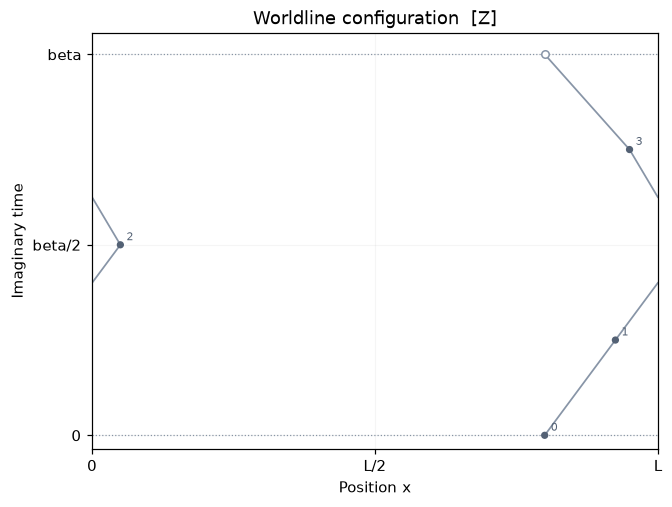

bead,slice,x,prev,next,image → next
0,0,3.2,3,1,0
1,1,3.7,0,2,1
2,2,0.2,1,3,-1
3,3,3.8,2,0,0


Winding: [0]


In [4]:
state = Configuration.from_closed_worldline(
    np.array([3.2, 3.7, 4.2, 3.8, 3.2]), box_length=4.0,
)
show_configuration(state, tau=1.0 / state.n_slices)
print("Winding:", state.cycle_winding().tolist())

## 3. 一次更新：平移（Displace）与接受判断

从这里开始，演示用的 simulation 与第 1 节的量测对象独立。
`step(move="…", trace=True)` 尝试指定更新，保存真实提议和决定，不自动量测。

**平移（Displace）会整体平移一个闭合世界线分量。**
该分量中的 beads 使用同一个平移量，连接和环绕数保持不变；含交换时，一个分量可能跨越多个 $\beta$。
下一节的位移（Wiggle）展示固定端点之间的局部路径重采样。

先观察理想气体里的整体平移。橙线是旧连接，蓝线是候选连接，灰线是本步未改变的连接。

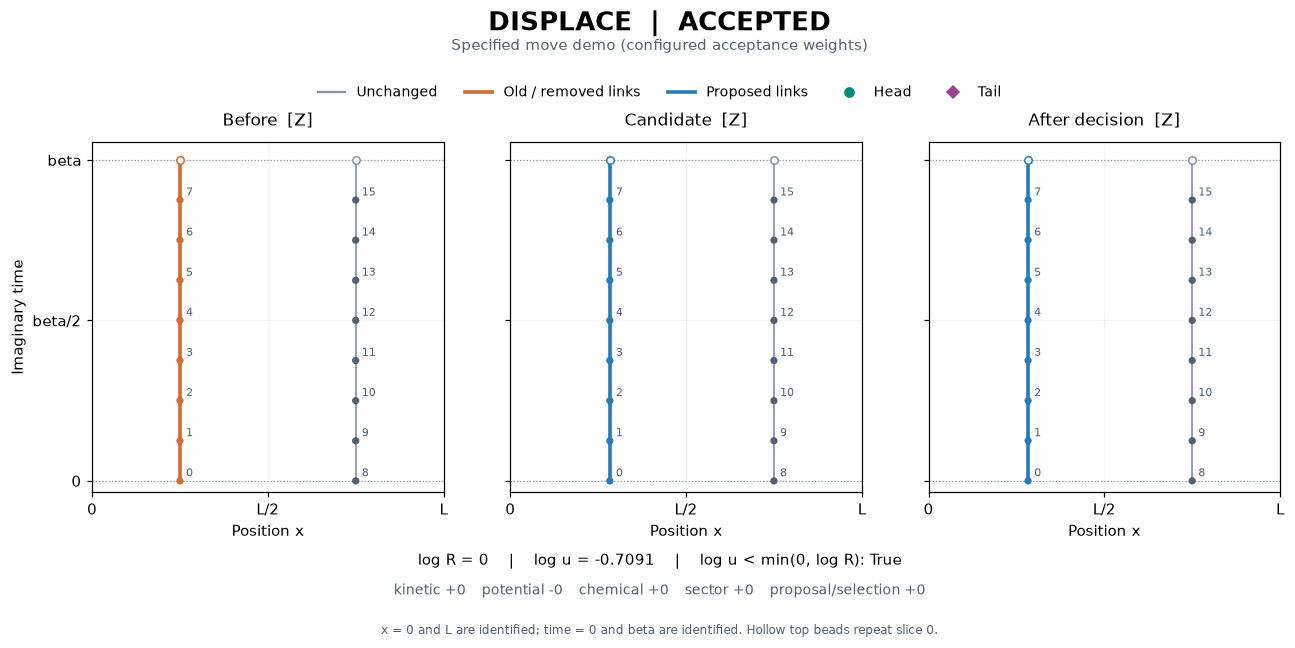

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,"(0, 1, 2, 3, 4, 5, 6, 7)"
新增 / 删除的 beads,() / ()
连接关系改变的 beads,()
head / tail（更新前 → 候选）,"(-1, -1) → (-1, -1)"


log R 的贡献,数值
kinetic,0
potential,-0
chemical,0
sector / measure,0
proposal / selection,0
总和 log R,0
"阈值 min(0, log R)",0
log u,-0.709055


提议概率分解,数值
log q forward,-0.693147
log q reverse,-0.693147
log p(move) forward,-2.48491
log p(move) reverse,-2.48491


共同平移量: (0.13200426890353523,)


In [5]:
displace_config = SimulationConfig.small_system(n_slices=8, seed=97531)
displace_sim = Simulation(displace_config)
displace_event = displace_sim.step(move="displace", trace=True)
show_step(displace_event, tau=displace_config.tau, details=True)
print("共同平移量:", displace_event.patch.metadata_dict()["displacement"])

### 怎样核对接受判断

表格和图底部读的是 sampler 实际保存的各项贡献：
$$
\log R = \Delta\log\pi_{\mathrm{kin}}
+\Delta\log\pi_{\mathrm{pot}}+\Delta\log\pi_{\mathrm{chem}}
+\Delta\log\pi_{\mathrm{sector/measure}}+\log(T_{\mathrm{rev}}/T_{\mathrm{fwd}}).
$$
接受条件为 $\log u < \min(0,\log R)$。此例为理想气体的对称整体平移，各项为零，因而接受。
下面只是核对记录，不另写一套采样或接受算法。

`status="proposed"` 表示已产生有效提议；最终有没有接受，要读 `event.accepted`。

In [6]:
decision = displace_event.breakdown
print("从记录核对:", decision.log_uniform < min(0.0, decision.log_ratio))
print("Sampler 的决定:", displace_event.accepted)
print("step 后的量测机会:", displace_sim.summary()["measurement_opportunities"])

从记录核对: True
Sampler 的决定: True
step 后的量测机会: 0


## 4. 位移（Wiggle）：固定端点，重采样中间路径

对应笔记的“位移”更新。它固定一段路径的两端，使用 Brownian bridge 重新采样内部 beads。
本例仍是理想气体，因此自由传播子的权重变化与提议密度之比相消。
留意端点与内部珠子的区别，以及蓝色路径跨周期边界时的画法。

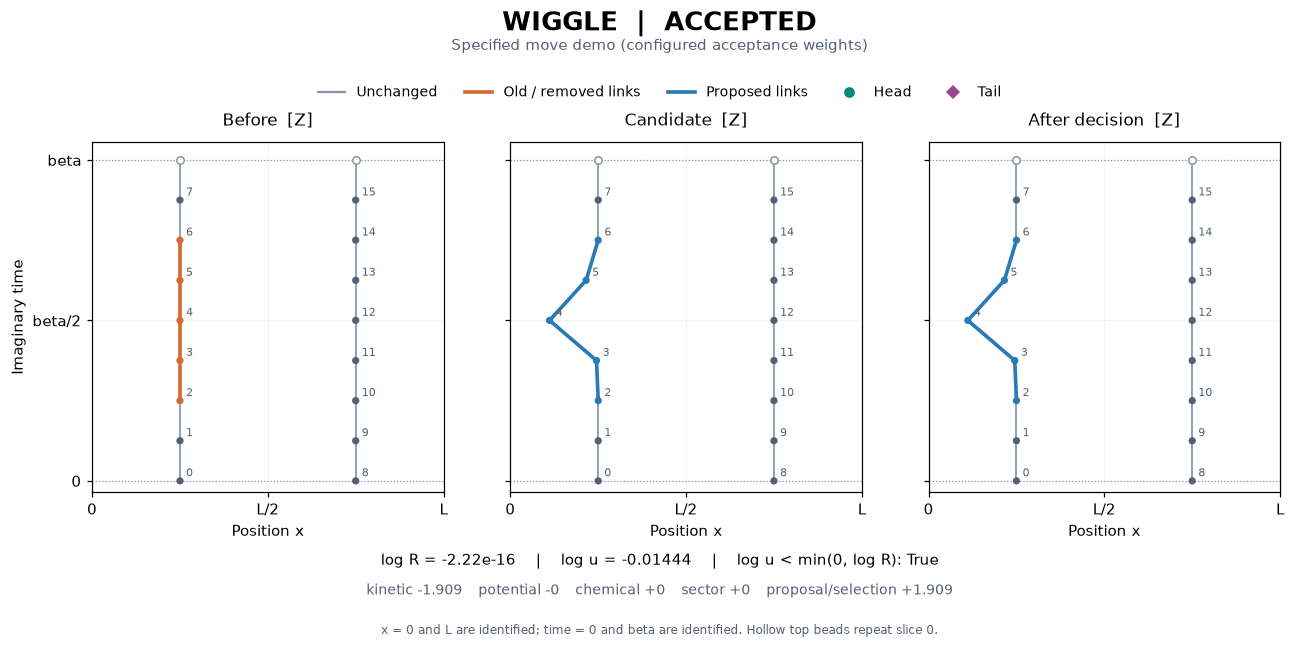

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,"(3, 4, 5)"
新增 / 删除的 beads,() / ()
连接关系改变的 beads,()
head / tail（更新前 → 候选）,"(-1, -1) → (-1, -1)"


log R 的贡献,数值
kinetic,-1.90851
potential,-0
chemical,0
sector / measure,0
proposal / selection,1.90851
总和 log R,-2.22045e-16
"阈值 min(0, log R)",-2.22045e-16
log u,-0.0144449


提议概率分解,数值
log q forward,-5.23505
log q reverse,-3.32653
log p(move) forward,-1.09861
log p(move) reverse,-1.09861


重采样路径的 bead IDs: (2, 3, 4, 5, 6)


In [7]:
wiggle_config = SimulationConfig.small_system(n_slices=8, seed=97531)
wiggle_sim = Simulation(wiggle_config)
wiggle_event = wiggle_sim.step(move="wiggle", trace=True)
show_step(wiggle_event, tau=wiggle_config.tau, details=True)
print("重采样路径的 bead IDs:", wiggle_event.patch.metadata_dict()["segment_ids"])

## 5. Open / Close：在 Z 与 G 扇区之间切换

对应笔记的“G 扇区与不完整世界线”和“打开与闭合”。
Open 从闭合构型中删除一段连接和内部 beads，留下 head 和 tail；Close 尝试在端点之间生成一段桥并闭合。
head 没有 outgoing link，tail 没有 incoming link。图中分别使用绿色圆点和紫色菱形。

先运行 Open。这个固定 seed 的提议会被接受。

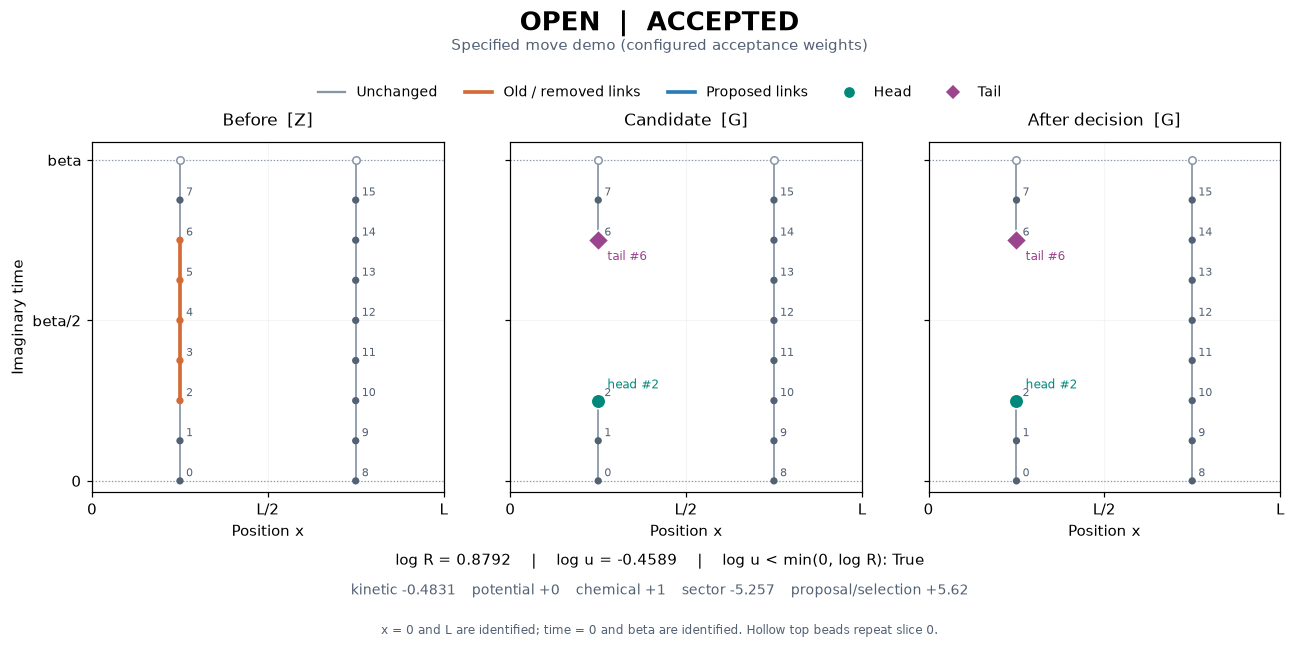

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,()
新增 / 删除的 beads,"() / (3, 4, 5)"
连接关系改变的 beads,"(2, 6)"
head / tail（更新前 → 候选）,"(-1, -1) → (2, 6)"


In [8]:
open_close_config = SimulationConfig.small_system(n_slices=8, seed=97531)
open_close_sim = Simulation(open_close_config)
open_event = open_close_sim.step(move="open", trace=True)
show_step(open_event, tau=open_close_config.tau)

### 被拒绝的 Close 仍有候选

继续尝试 Close。本例中间面板确实生成了 Z 构型，但最终拒绝，因此右面板仍是原来的 G 构型。
`candidate()` 从记录重建这次提议，不重新抽取随机数；可以随时回看。

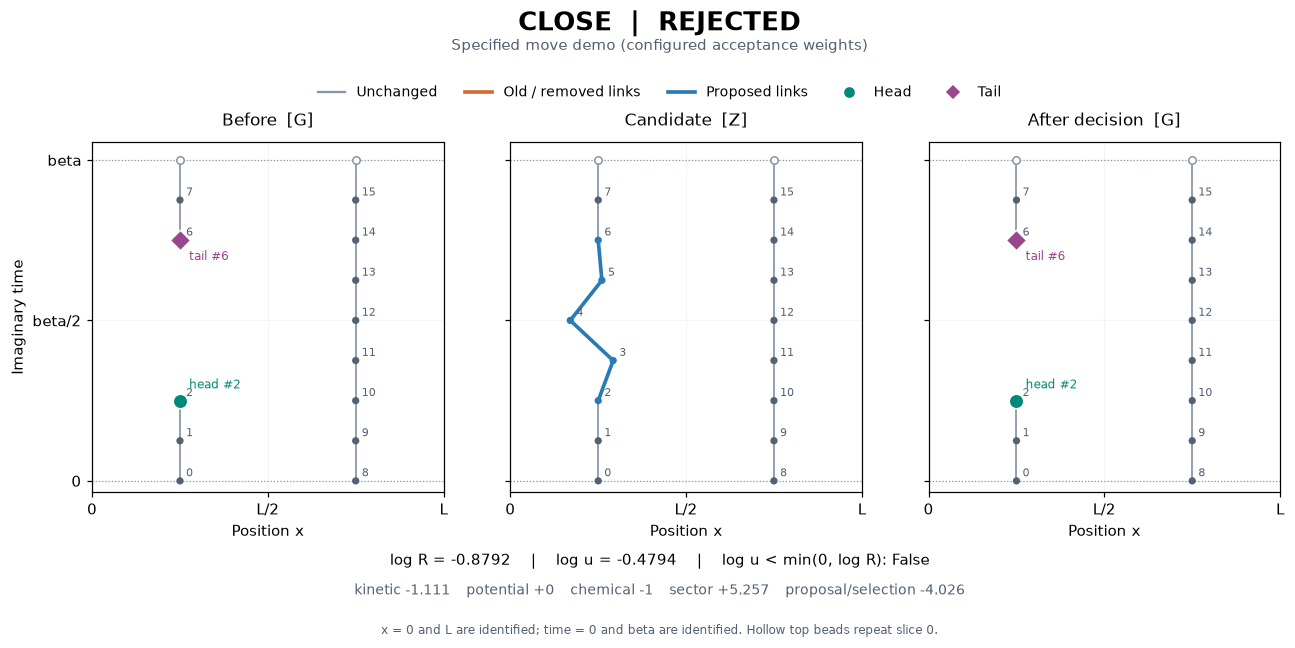

本次提议,记录
状态 / 接受,proposed / False
移动的 beads,()
新增 / 删除的 beads,"(3, 4, 5) / ()"
连接关系改变的 beads,"(2, 6)"
head / tail（更新前 → 候选）,"(2, 6) → (-1, -1)"


log R 的贡献,数值
kinetic,-1.1106
potential,0
chemical,-1
sector / measure,5.2575
proposal / selection,-4.02612
总和 log R,-0.879218
"阈值 min(0, log R)",-0.879218
log u,-0.479407


提议概率分解,数值
log q forward,-0.538231
log q reverse,-4.56435
log p(move) forward,-2.48491
log p(move) reverse,-2.48491


候选扇区: Z
实际扇区: G


In [9]:
close_event = open_close_sim.step(move="close", trace=True)
show_step(close_event, tau=open_close_config.tau, details=True)
candidate = close_event.candidate()
print("候选扇区:", candidate.sector.value)
print("实际扇区:", open_close_sim.state.sector.value)

### 再看一次被接受的 Close

用新的 simulation 和 seed=2 复现另一个例子。前置 Open 同样通过普通 Metropolis 决定，
没有强制接受或隐藏重试。Close 接受时，中间与右侧的构型相同，端点消失。

前置 Open 接受: True


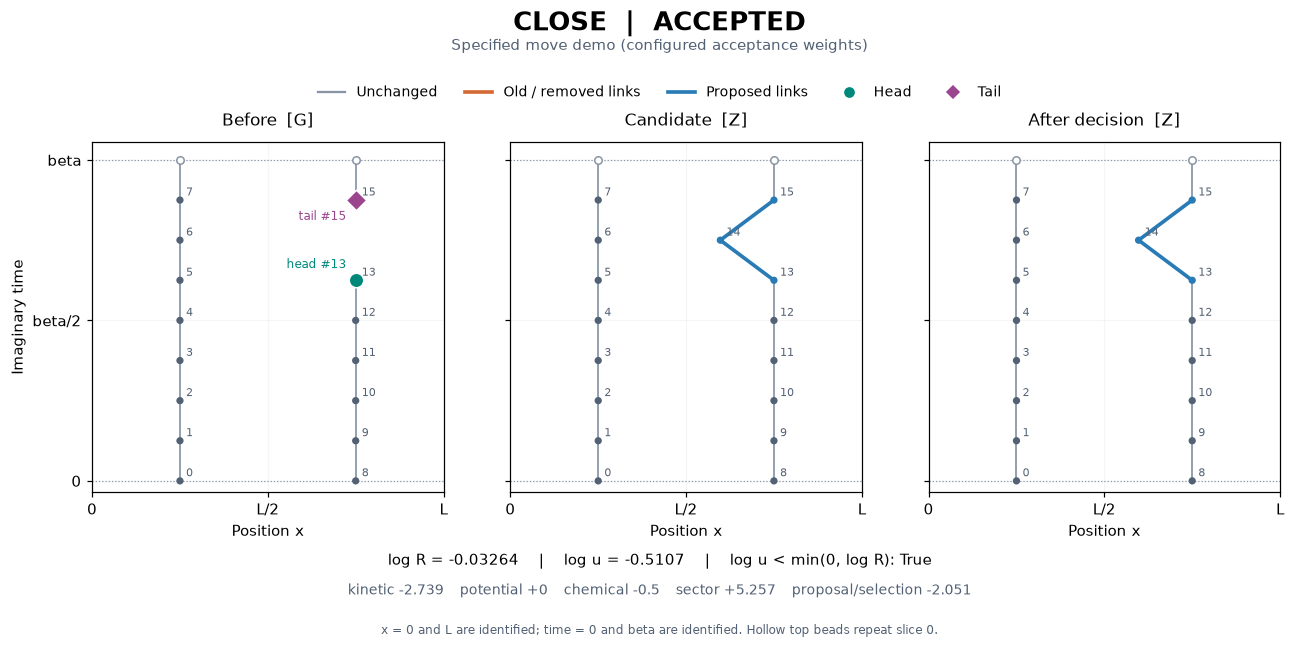

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,()
新增 / 删除的 beads,"(14,) / ()"
连接关系改变的 beads,"(13, 15)"
head / tail（更新前 → 候选）,"(13, 15) → (-1, -1)"


In [10]:
accepted_close_config = SimulationConfig.small_system(n_slices=8, seed=2)
accepted_close_sim = Simulation(accepted_close_config)
setup_open = accepted_close_sim.step(move="open", trace=True)
print("前置 Open 接受:", setup_open.accepted)
accepted_close_event = accepted_close_sim.step(move="close", trace=True)
show_step(accepted_close_event, tau=accepted_close_config.tau)

### 不适用与拒绝的区别

初始 Z 构型直接尝试 Close：没有 worm 端点，因而没有候选，也没有 Metropolis 随机数。
这与上一幅“产生候选但拒绝”的情况不同。

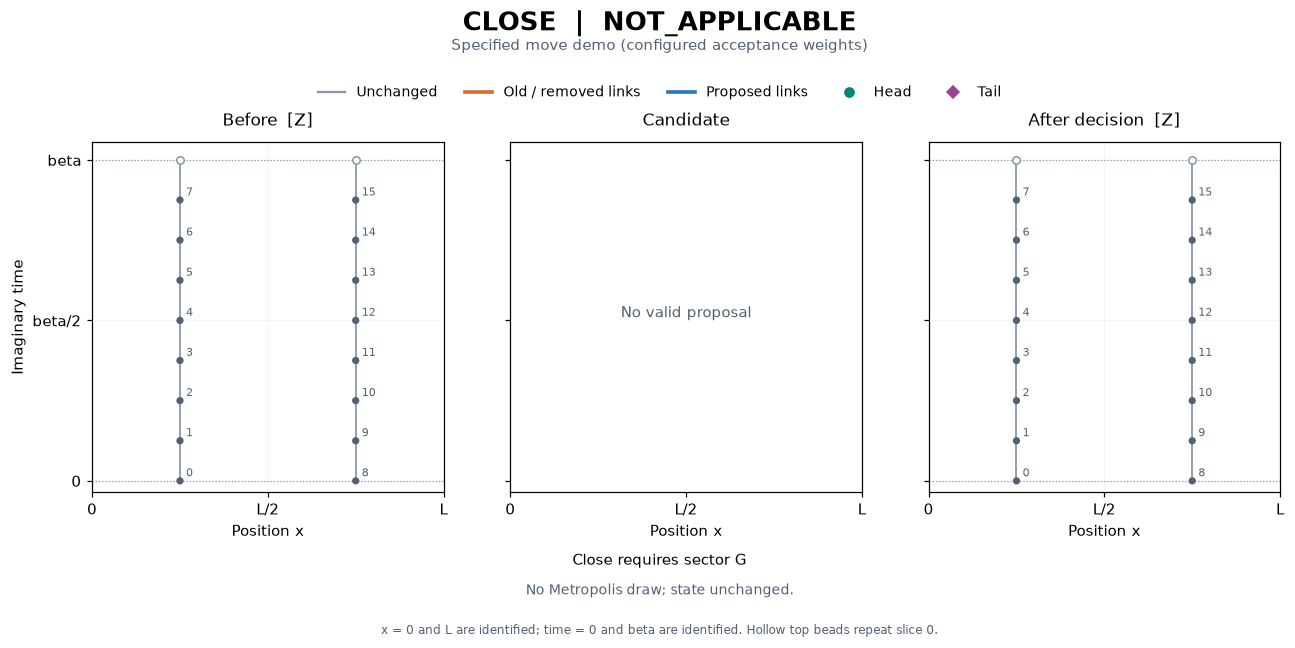

本次提议,记录
状态 / 接受,not_applicable / False
移动的 beads,()
新增 / 删除的 beads,() / ()
连接关系改变的 beads,()
head / tail（更新前 → 候选）,"(-1, -1) → (-1, -1)"


原因: Close requires sector G
候选: None


In [11]:
invalid_sim = Simulation(SimulationConfig.small_system(n_slices=8))
inapplicable_event = invalid_sim.step(move="close", trace=True)
show_step(inapplicable_event, tau=invalid_sim.config.tau)
print("原因:", inapplicable_event.patch.invalid_reason)
print("候选:", inapplicable_event.candidate())

## 6. Advance / Recede：开放世界线的生长与缩短

对应笔记的“前进和后退”。Advance 从 head 继续生成自由路径，把 head 移到新末端；
Recede 从 head 删除一段路径，把 head 移回保留下来的末端。二者都留在 G 扇区。

这里用 seed=5 的 Insert 作为前置更新，保留其事件供第 8 节对照。
“前进”的 move 名称与 `Simulation.advance()` 不同：后者是推进热化、量测生命周期的接口。

前置 Insert: proposed accepted: True


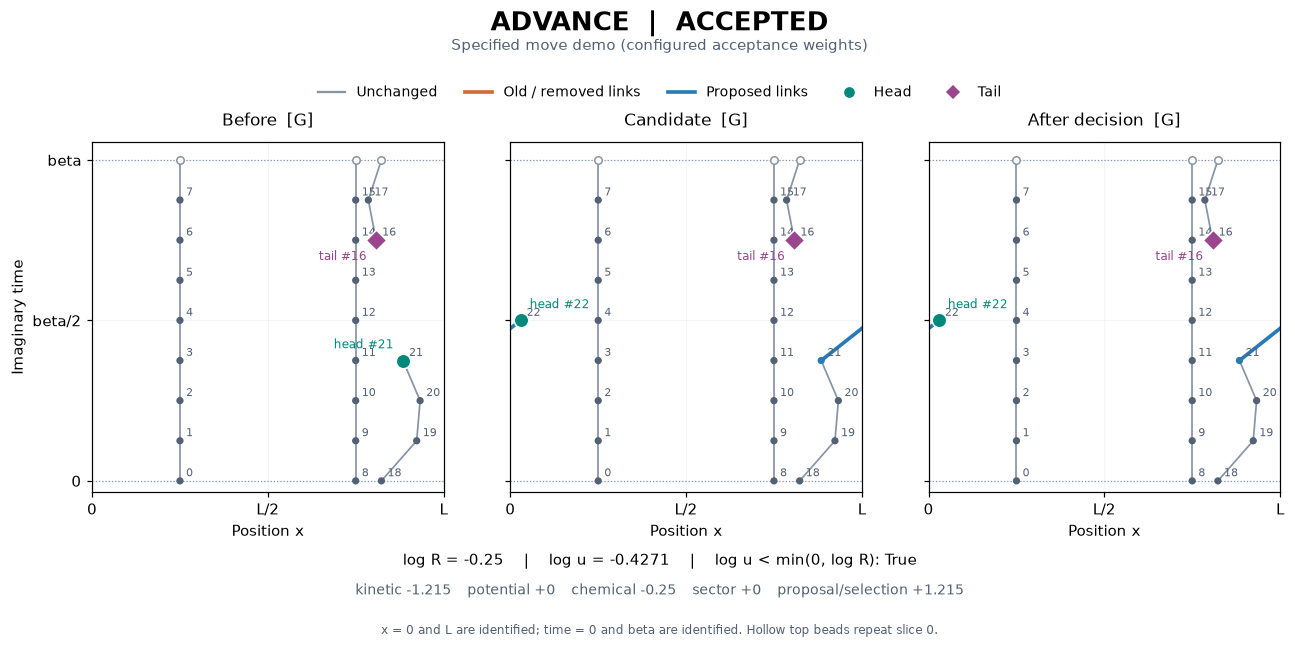

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,()
新增 / 删除的 beads,"(22,) / ()"
连接关系改变的 beads,"(21,)"
head / tail（更新前 → 候选）,"(21, 16) → (22, 16)"


In [12]:
growth_config = SimulationConfig.small_system(n_slices=8, seed=5)
growth_sim = Simulation(growth_config)
insert_event = growth_sim.step(move="insert", trace=True)
print("前置 Insert:", insert_event.status.value, "accepted:", insert_event.accepted)
advance_event = growth_sim.step(move="advance", trace=True)
show_step(advance_event, tau=growth_config.tau)

继续执行 Recede。本例恰好删除刚刚长出的那一个 bead，回到生长前的构型。
普通随机链中，Recede 抽到的长度未必与前一次 Advance 相同。

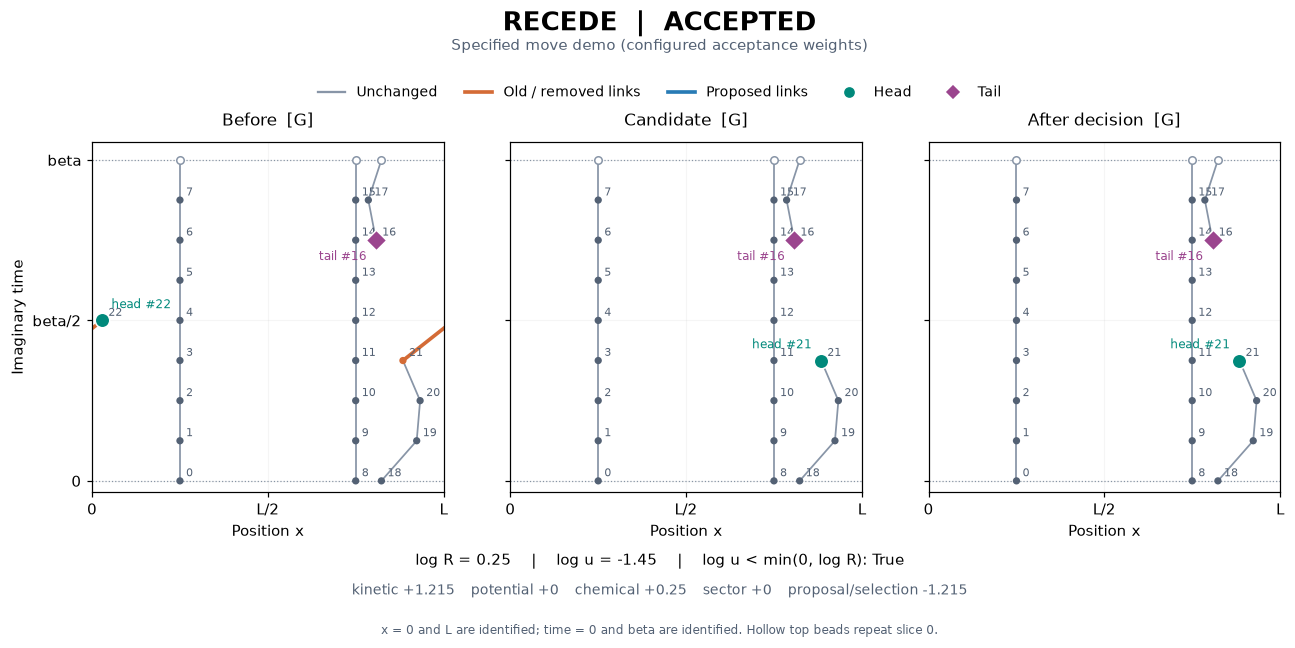

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,()
新增 / 删除的 beads,"() / (22,)"
连接关系改变的 beads,"(21,)"
head / tail（更新前 → 候选）,"(22, 16) → (21, 16)"


In [13]:
recede_event = growth_sim.step(move="recede", trace=True)
show_step(recede_event, tau=growth_config.tau)

## 7. Swap：重新连接世界线

对应笔记的交换更新分步图。新的 simulation 用 seed=1 先 Open，再 Swap。
Swap 生成一段连接到候选 bead α 的桥，拆开原来的路径，使 ζ 成为新的 head；tail 保持不变。
注意这里只展示这次交换更新的局部重连，全局交换环要在闭合后读取。

图上的 bead IDs 与下方 patch metadata 可以互相对照：`old_head`、`candidate_id`（α）、`new_head`（ζ）。

前置 Open 接受: True


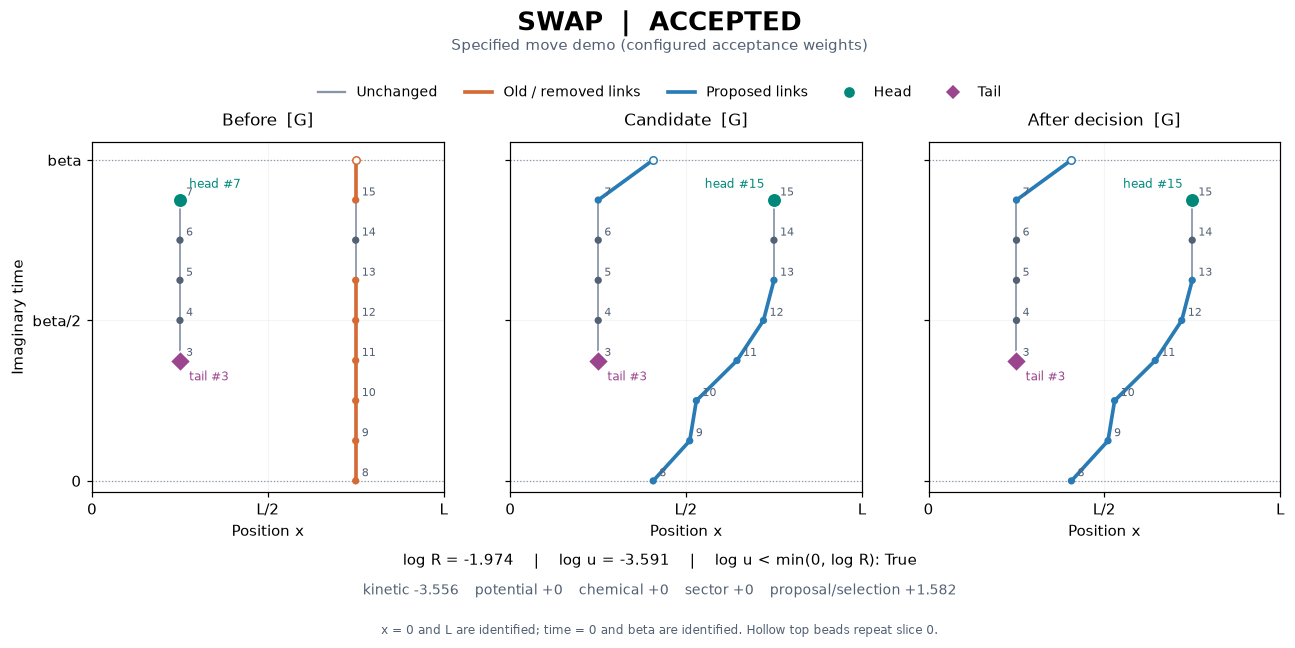

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,"(8, 9, 10, 11, 12)"
新增 / 删除的 beads,() / ()
连接关系改变的 beads,"(7, 8, 15)"
head / tail（更新前 → 候选）,"(7, 3) → (15, 3)"


交换中的角色,bead ID
旧 head（I）,7
连接目标（α）,13
新 head（ζ）,15


In [14]:
swap_config = SimulationConfig.small_system(n_slices=8, seed=1)
swap_sim = Simulation(swap_config)
swap_open = swap_sim.step(move="open", trace=True)
print("前置 Open 接受:", swap_open.accepted)
swap_event = swap_sim.step(move="swap", trace=True)
show_step(swap_event, tau=swap_config.tau)
swap_metadata = swap_event.patch.metadata_dict()
display_table(("交换中的角色", "bead ID"), [
    ("旧 head（I）", swap_metadata["old_head"]),
    ("连接目标（α）", swap_metadata["candidate_id"]),
    ("新 head（ζ）", swap_metadata["new_head"]),
])

## 8. Insert / Remove：插入和删除开放路径

对应笔记的“更多更新”。Insert 在 Z 构型中新增一条开放路径，而不是打开已有闭合路径；
Remove 则尝试删除可移除的开放路径，回到 Z 扇区。

先回看第 6 节的 Insert。它展示的是那次保存的历史事件，尽管 simulation 后来已经前进、后退，图不会变化。

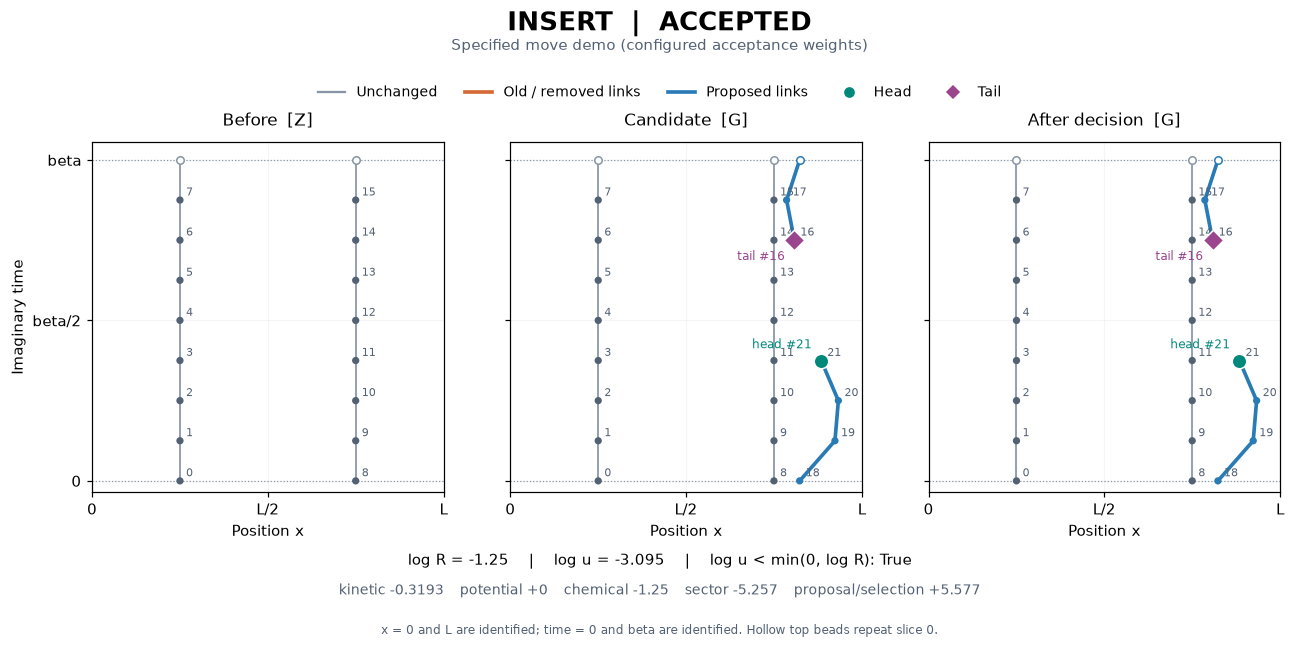

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,()
新增 / 删除的 beads,"(16, 17, 18, 19, 20, 21) / ()"
连接关系改变的 beads,()
head / tail（更新前 → 候选）,"(-1, -1) → (21, 16)"


In [15]:
show_step(insert_event, tau=growth_config.tau)

接着在第 6 节完成 Recede 的构型上尝试 Remove。本例接受，刚插入的开放路径被删除，原来的闭合路径保留。

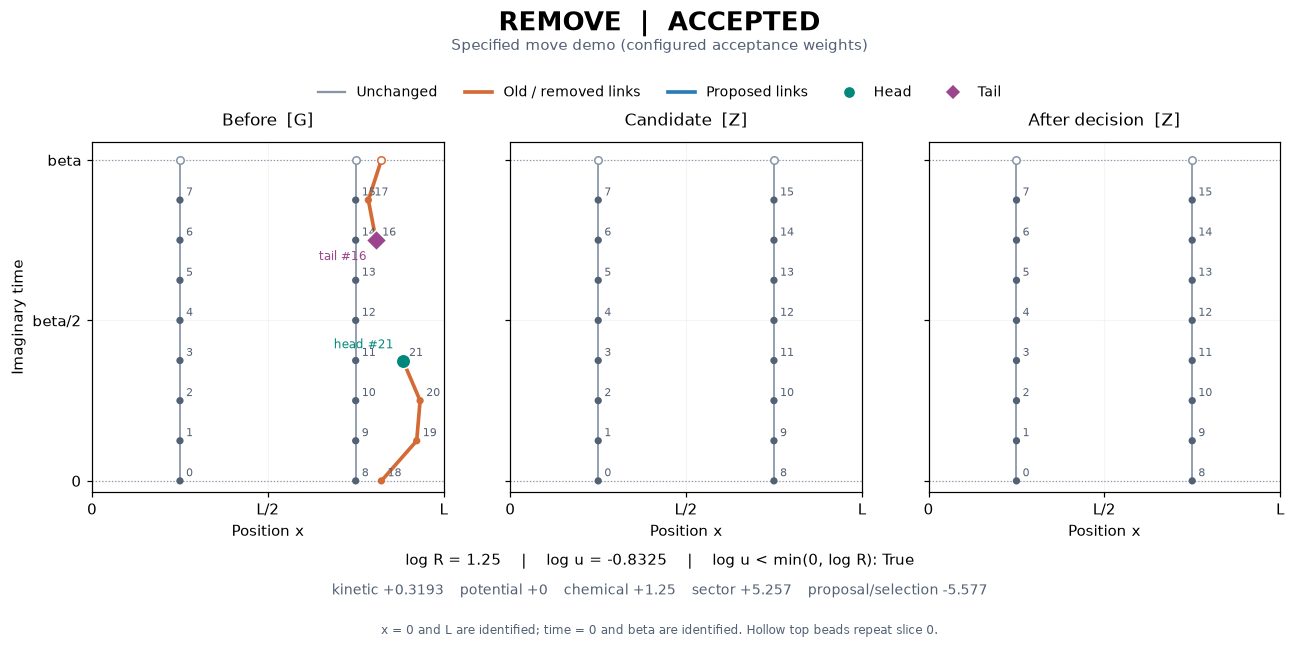

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,()
新增 / 删除的 beads,"() / (16, 17, 18, 19, 20, 21)"
连接关系改变的 beads,()
head / tail（更新前 → 候选）,"(21, 16) → (-1, -1)"


In [16]:
remove_event = growth_sim.step(move="remove", trace=True)
show_step(remove_event, tau=growth_config.tau)

## 9. 把九类更新的记录放在一起

表格包括真实的拒绝和不适用事件。`proposed` 与 `accepted` 是两个不同的问题。
这些事件来自手工安排的独立演示，它们的频次不代表正常随机链的平衡统计。

In [17]:
demo_events = [displace_event, wiggle_event, open_event, close_event,
               accepted_close_event, inapplicable_event, advance_event,
               recede_event, swap_event, insert_event, remove_event]
display_table(("move", "before", "candidate", "after", "status", "accepted"), [
    (e.move_name, e.before["sector"],
     e.candidate().sector.value if e.candidate() is not None else None,
     e.after["sector"], e.status.value, e.accepted)
    for e in demo_events
])

move,before,candidate,after,status,accepted
displace,Z,Z,Z,proposed,True
wiggle,Z,Z,Z,proposed,True
open,Z,G,G,proposed,True
close,G,Z,G,proposed,False
close,G,Z,Z,proposed,True
close,Z,—,Z,not_applicable,False
advance,G,G,G,proposed,True
recede,G,G,G,proposed,True
swap,G,G,G,proposed,True
insert,Z,G,G,proposed,True


## 10. 下一次可以怎样修改

先改某组 `small_system()` 的 seed，再从这一组的初始化单元开始执行。
不同 seed 下，前置更新可能被拒绝，后续更新也可能不适用，图会如实显示这些情况。
改变 `n_slices` 可观察不同虚时分辨率；改 `max_segment_links` 可观察不同长度的路径更新。

下面独立展示一个带 Gaussian 排斥对势的位移（Wiggle）。势能贡献通常不再为零，
可以把它与第 4 节的自由桥对照。所有修改仍由库的真实提议和接受逻辑完成。

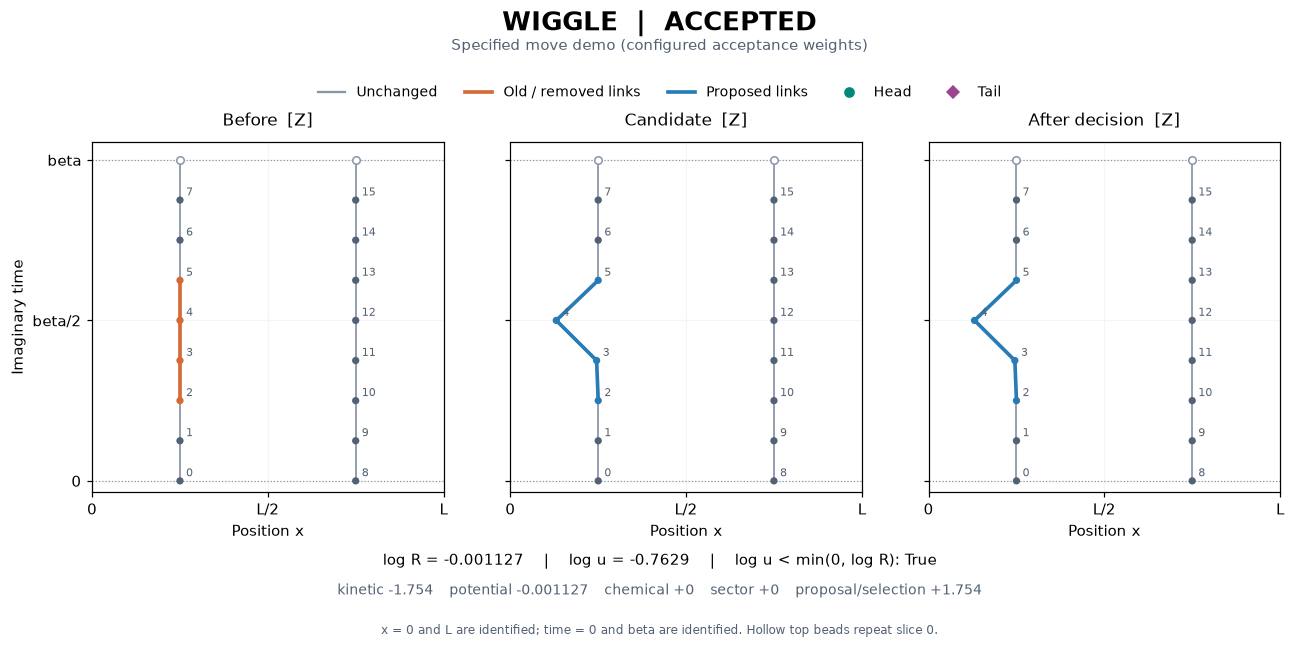

本次提议,记录
状态 / 接受,proposed / True
移动的 beads,"(3, 4)"
新增 / 删除的 beads,() / ()
连接关系改变的 beads,()
head / tail（更新前 → 候选）,"(-1, -1) → (-1, -1)"


log R 的贡献,数值
kinetic,-1.7542
potential,-0.00112711
chemical,0
sector / measure,0
proposal / selection,1.7542
总和 log R,-0.00112711
"阈值 min(0, log R)",-0.00112711
log u,-0.762895


提议概率分解,数值
log q forward,-4.42907
log q reverse,-2.67487
log p(move) forward,-1.09861
log p(move) reverse,-1.09861


In [18]:
interaction_config = SimulationConfig.small_system(
    n_slices=8, seed=97531,
    pair="periodized_gaussian", epsilon=1.0, sigma=0.5,
)
interaction_config = replace(
    interaction_config,
    moves=replace(interaction_config.moves, max_segment_links=3),
)
interaction_sim = Simulation(interaction_config)
interaction_event = interaction_sim.step(move="wiggle", trace=True)
show_step(interaction_event, tau=interaction_config.tau, details=True)

更多公式与实现约定见 [物理推导](../derivations.md)，API 语义见 [Python 使用指南](../docs/python_workflow.md)，
颜色和周期链接的读图说明见 [可视化指南](../docs/visualize_updates.md)。

正式物理计算从第 1 节的正常随机 `advance()` 开始，使用独立的 simulation；
逐步观察仍可调用同一个 `step(trace=True)` 接口。